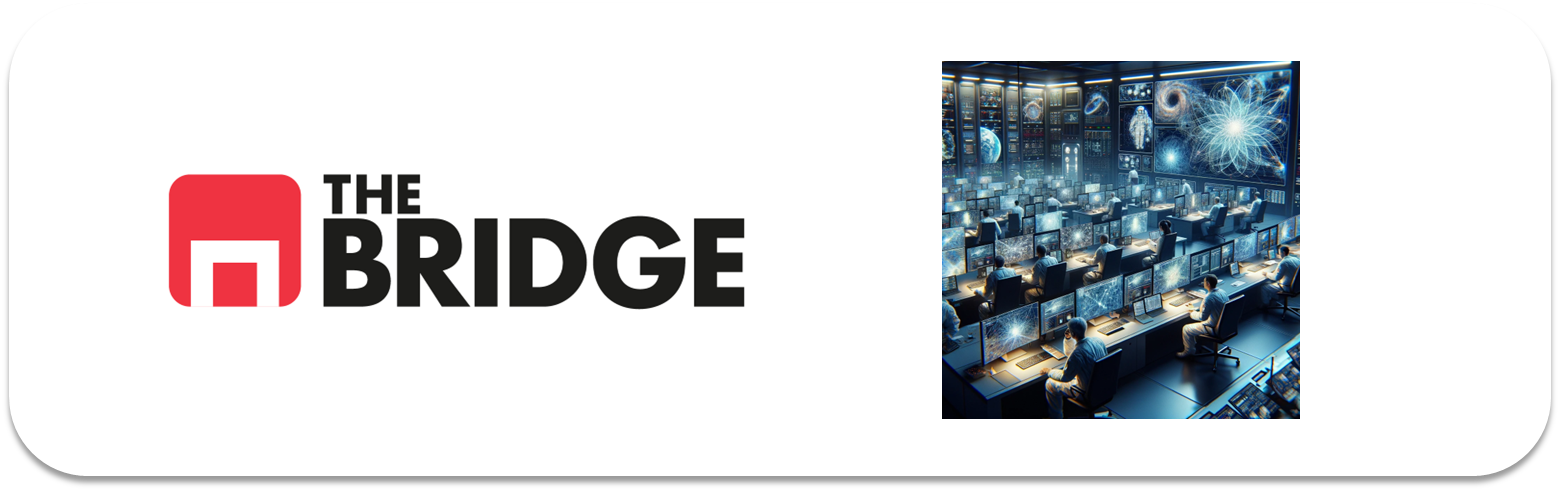

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [47]:
import os
import numpy as np
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns



### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### **1. Creación de datasets**

1.1. + 1.2. Creación de datasets + split

In [30]:
TAM = 32

def cargar_imagenes(lista_directorios):
    X = []
    y = []
    nombres = []

    for directorio in lista_directorios:
        for fichero in sorted(os.listdir(directorio)):
            ruta_imagen = directorio + "/" + fichero

            # Lectura de imagen + tamaño (32x32) (lo definimos arriba)
            imagen = cv2.imread(ruta_imagen)
            imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
            imagen = cv2.resize(imagen, (TAM, TAM))
            X.append(imagen)

            # Clase en el nombre, x tanto fem split
            clase = fichero.split(".")[0]
            if clase == "cat":
                y.append(0)
            else:
                y.append(1)

            nombres.append(ruta_imagen)

    return np.array(X), np.array(y), nombres

In [31]:
directorios_train = ["./data/github_train_0",
                     "./data/github_train_1",
                     "./data/github_train_2",
                     "./data/github_train_3"]

X_train, y_train, nombres_train = cargar_imagenes(directorios_train)
X_test, y_test, nombres_test = cargar_imagenes(["./data/github_test"])

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Rango de valores:", X_train.min(), "-", X_train.max())
print("Gatos y perros en train:", np.bincount(y_train))

Train: (4000, 32, 32, 3) (4000,)
Test: (1000, 32, 32, 3) (1000,)
Rango de valores: 0 - 255
Gatos y perros en train: [2000 2000]


### Comprobación de la carga

Los datasets se han cargado correctamente:

- **Train:** 4000 imágenes de 32x32 píxeles y 3 canales de color (RGB), con sus 4000 etiquetas correspondientes.
- **Test:** 1000 imágenes con el mismo formato.
- **Rango de valores:** los píxeles van de 0 a 255, por lo que habrá que normalizarlos antes de entrenar.
- **Balance de clases:** 2000 gatos y 2000 perros, un dataset perfectamente equilibrado.

Que las clases estén balanceadas es relevante por dos motivos: el **accuracy** será una métrica fiable (no va a estar inflada por una clase mayoritaria) y sabemos que el punto de partida a superar es el 50%, que es lo que acertaría un modelo que respondiera siempre lo mismo.

La forma **(32, 32, 3)** de cada imagen es la que usaremos como **input_shape** en la primera capa de la red convolucional.

Escalado

In [32]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [33]:
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Rango de valores:", X_train.min(), "-", X_train.max())

Train: (4000, 32, 32, 3) (4000,)
Test: (1000, 32, 32, 3) (1000,)
Rango de valores: 0.0 - 1.0


##### Barajamos la carga

In [34]:
from sklearn.utils import shuffle

X_train, y_train, nombres_train = shuffle(X_train, y_train, nombres_train, random_state=42)

print("Primeras 20 etiquetas:", y_train[:20])

Primeras 20 etiquetas: [0 1 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0]


La primera vez que modelamos, el **val_accuracy** fue 0 porque, al cargar las imágenes, los datos quedaron ordenados por clase: los directorios **github_train_0** y **github_train_1** contienen únicamente gatos, y **github_train_2** y **github_train_3** únicamente perros. Como los recorrimos en orden, **y_train** acabó siendo 2000 ceros seguidos de 2000 unos.

El problema es que **validation_split=0.2** no baraja nada: aparta directamente el último 20% de los datos tal y como llegan. Ese último 20% eran 800 perros y ningún gato, así que el modelo estaba validando contra una única clase.

La solución es barajar el conjunto de train antes de entrenar, manteniendo la correspondencia entre imágenes, etiquetas y nombres de fichero.

### **2. Mini-EDA**

2.1. Nulos

In [35]:
print("Nulos", np.isnan(X_train).sum())

Nulos 0


2.2. Estadísticas básicas de los píxeles

In [36]:
print("Media:", X_train.mean())
print("Desviación típica:", X_train.std())


Media: 0.4536156246808619
Desviación típica: 0.2589327826818346


2.3. Brillo medio de cada clase (perro vs gato)

In [37]:
media_gatos = X_train[y_train == 0].mean()
media_perros = X_train[y_train == 1].mean()
print("Brillo medio gatos:", media_gatos)
print("Brillo medio perros:", media_perros)


Brillo medio gatos: 0.4494824123008578
Brillo medio perros: 0.45774883706086605


2.4. Balance de clases en test tb

In [38]:
print("Gatos y perros en test:", np.bincount(y_test))

Gatos y perros en test: [500 500]


2.5. Representación gráfica

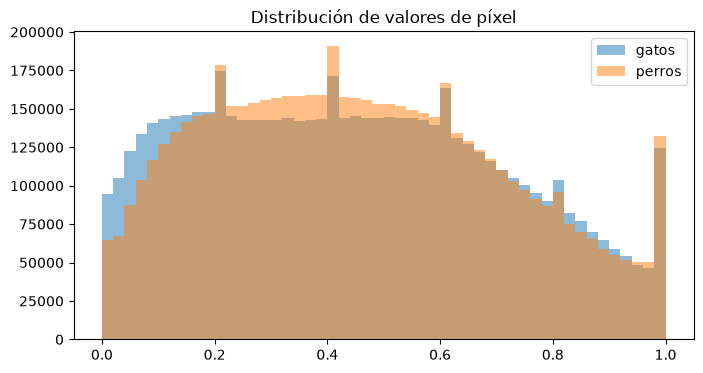

In [39]:
# Distribución de los valores de píxel
plt.figure(figsize=(8, 4))
plt.hist(X_train[y_train == 0].ravel(), bins=50, alpha=0.5, label="gatos")
plt.hist(X_train[y_train == 1].ravel(), bins=50, alpha=0.5, label="perros")
plt.title("Distribución de valores de píxel")
plt.legend()
plt.show()

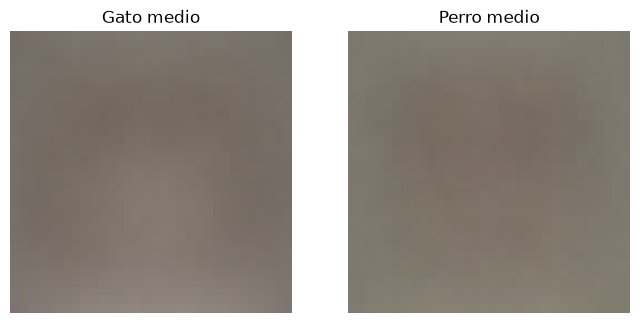

In [40]:
plt.figure(figsize=(8, 4))

# Imagen media de los gatos
plt.subplot(1, 2, 1)
imagen_media_gatos = X_train[y_train == 0].mean(axis=0)
plt.imshow(imagen_media_gatos)
plt.title("Gato medio")
plt.axis("off")

# Imagen media de los perros
plt.subplot(1, 2, 2)
imagen_media_perros = X_train[y_train == 1].mean(axis=0)
plt.imshow(imagen_media_perros)
plt.title("Perro medio")
plt.axis("off")

plt.show()

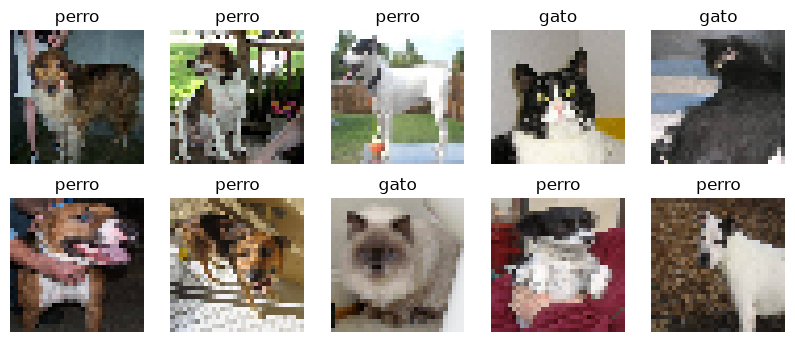

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(10):
    indice = np.random.randint(0, len(X_train))
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[indice])
    if y_train[indice] == 0:
        plt.title("gato")
    else:
        plt.title("perro")
    plt.axis("off")
plt.show()

### Conclusiones de la visualización

**Distribución de píxeles:** las curvas de ambas clases se solapan casi por completo a lo largo de todo el rango. Los picos en 0.0 y 1.0 corresponden a zonas de negro y blanco puro (fondos, sobreexposiciones), y aparecen en las dos clases por igual. No hay ningún tramo de intensidad que sea característico de gatos o de perros.

**Imágenes medias:** al promediar las 2000 imágenes de cada clase se obtienen dos manchas marrón grisáceo prácticamente indistinguibles entre sí. Ni la forma ni el color permiten diferenciarlas, y no se aprecia ninguna silueta reconocible.

**Muestra de imágenes:** las fotos son muy heterogéneas. Los animales aparecen en poses distintas, a distintas distancias, con fondos variados, algunos acompañados de personas y en ocasiones sin el cuerpo completo. A 32x32 muchas resultan difíciles de clasificar incluso a simple vista.

Las tres visualizaciones apuntan a lo mismo: **no existen atajos estadísticos** para resolver este problema. Al no estar los animales centrados ni encuadrados de forma homogénea, el modelo tendrá que aprender a reconocer patrones locales (orejas, hocicos, texturas de pelo) con independencia de dónde aparezcan en la imagen. Esta invarianza a la posición es justamente la propiedad que aportan las capas convolucionales.

### **3. Entrenamiento + EarlyStopping**

In [42]:
model = Sequential()

# Primer bloque convolucional
model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))

# Segundo bloque convolucional
model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(MaxPooling2D((2, 2)))

# Tercer bloque convolucional
model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(MaxPooling2D((2, 2)))

# Clasificador
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

#### EarlyStopping

In [43]:
early_stopping = EarlyStopping(monitor="val_loss",
                               patience=5,
                               restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5503 - loss: 0.6899 - val_accuracy: 0.6212 - val_loss: 0.6566
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6128 - loss: 0.6552 - val_accuracy: 0.6612 - val_loss: 0.6163
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6584 - loss: 0.6191 - val_accuracy: 0.6212 - val_loss: 0.6430
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6844 - loss: 0.5986 - val_accuracy: 0.6675 - val_loss: 0.6222
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6828 - loss: 0.5903 - val_accuracy: 0.6675 - val_loss: 0.6097
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7178 - loss: 0.5508 - val_accuracy: 0.6975 - val_loss: 0.5776
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7434 - loss: 0.5176 - val_accuracy: 0.6575 - val_loss: 0.6285
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7634 - loss: 0.4819 - val_accuracy: 0.

Representación gráfica

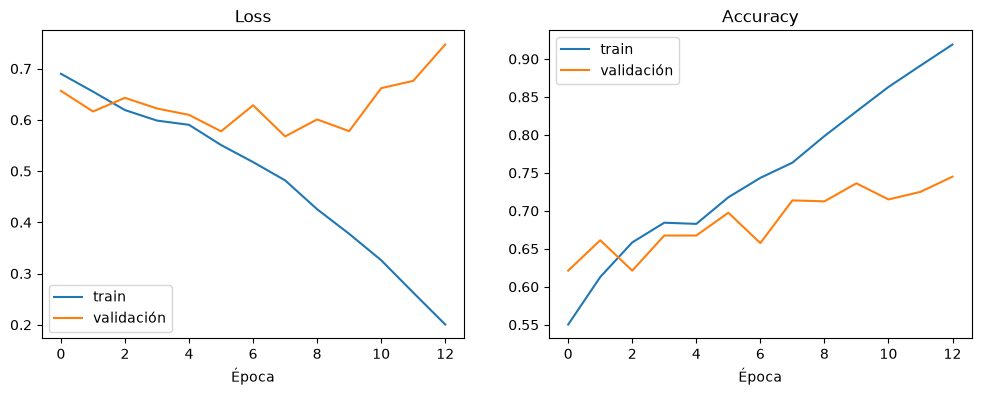

In [44]:
plt.figure(figsize=(12, 4))

# Curva de loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validación")
plt.title("Loss")
plt.xlabel("Época")
plt.legend()

# Curva de accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validación")
plt.title("Accuracy")
plt.xlabel("Época")
plt.legend()

plt.show()

In [45]:
mejor_epoca = np.argmin(history.history["val_loss"])
print("Mejor época:", mejor_epoca + 1)
print("Mejor val_loss:", history.history["val_loss"][mejor_epoca])
print("Épocas entrenadas en total:", len(history.history["loss"]))

Mejor época: 8
Mejor val_loss: 0.5677268505096436
Épocas entrenadas en total: 13


### Historial de entrenamiento

El entrenamiento paró en la **época 13** y el EarlyStopping recuperó los pesos de la **época 8**, donde la **val_loss** tocó su mínimo (0.5677).

Las curvas muestran **sobreajuste**: a partir de la época 8 la loss de entrenamiento sigue bajando (hasta 0.20) mientras la de validación empieza a subir. Ahí es donde el modelo dejó de aprender patrones generales y empezó a memorizar las imágenes del train. Se confirma en el accuracy: 92% en entrenamiento frente al 74% en validación.

El **val_accuracy** mejora un poco aunque la **val_loss** empeore porque miden cosas distintas: el accuracy solo cuenta aciertos, la loss tiene en cuenta la confianza. El modelo acierta algo más, pero falla con mucha más seguridad. Esos errores confiados son justamente lo que necesitaremos en el punto 5.

### **4. Evaluación del modelo vs. test**

4.1. Evaluación

In [49]:
loss_test, accuracy_test = model.evaluate(X_test, y_test)
print("Loss en test:", loss_test)
print("Accuracy en test:", accuracy_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.5828
Loss en test: 0.5827765464782715
Accuracy en test: 0.7099999785423279


4.2. Predicciones

In [50]:
probabilidades = model.predict(X_test)
predicciones = (probabilidades > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


4.3. Classf. report

In [51]:
print(classification_report(y_test, predicciones, target_names=["gato", "perro"]))

              precision    recall  f1-score   support

        gato       0.71      0.72      0.71       500
       perro       0.71      0.70      0.71       500

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.71      0.71      1000



4.4. Matriz de confusión

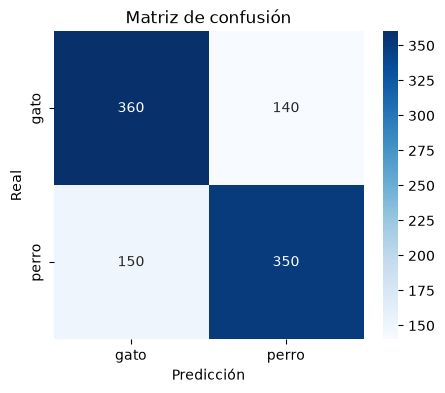

In [52]:
matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["gato", "perro"],
            yticklabels=["gato", "perro"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

### Evaluación del modelo

El modelo alcanza un **71% de accuracy** sobre las 1000 imágenes de test, prácticamente el mismo resultado que en validación (71.4%). Que ambas cifras coincidan indica que el modelo generaliza de forma consistente a datos que no ha visto nunca.

**Reporte de clasificación:** precision, recall y f1-score son 0.71 para ambas clases. Como el dataset está balanceado (500 gatos y 500 perros), el accuracy es una métrica fiable aquí y no está inflada por ninguna clase mayoritaria.

**Matriz de confusión:** el modelo acierta 360 gatos y 350 perros. Los errores están repartidos de forma muy simétrica: **140 gatos clasificados como perros** y **150 perros clasificados como gatos**. No hay sesgo hacia ninguna de las dos clases, el modelo se equivoca por igual en ambas direcciones.

Un 71% sobre imágenes de 32x32 es un resultado razonable teniendo en cuenta la pérdida de detalle que supone esa resolución. Estos 290 errores son el material de partida del punto 5: de ellos hay que seleccionar el 10% cometido con mayor confianza en cada clase.

### **5. Selección**

5.1. Aplanar lass probabilidades

In [54]:
# Ahora mismo ppredict devuelve (1000, 1) y queremos (1000,)
probabilidades = probabilidades.flatten()
predicciones = predicciones.flatten()

5.2. Estadísticas pre-selección

In [55]:
# Gatos (0) clasificados como perros (1)
indices_gatos_fallados = []
for i in range(len(y_test)):
    if y_test[i] == 0 and predicciones[i] == 1:
        indices_gatos_fallados.append(i)

# Perros (1) clasificados como gatos (0)
indices_perros_fallados = []
for i in range(len(y_test)):
    if y_test[i] == 1 and predicciones[i] == 0:
        indices_perros_fallados.append(i)

print("Gatos fallados:", len(indices_gatos_fallados))
print("Perros fallados:", len(indices_perros_fallados))

Gatos fallados: 140
Perros fallados: 150


In [56]:
# Los gatos peor clasificados: mayor probabilidad de ser perro
gatos_ordenados = sorted(indices_gatos_fallados,
                         key=lambda i: probabilidades[i],
                         reverse=True)

# Los perros peor clasificados: menor probabilidad de ser perro
perros_ordenados = sorted(indices_perros_fallados,
                          key=lambda i: probabilidades[i])

# Nos quedamos con el 10% de cada uno
n_gatos = int(len(gatos_ordenados) * 0.1)
n_perros = int(len(perros_ordenados) * 0.1)

peores_gatos = gatos_ordenados[:n_gatos]
peores_perros = perros_ordenados[:n_perros]

print("Seleccionados:", n_gatos, "gatos y", n_perros, "perros")

Seleccionados: 14 gatos y 15 perros


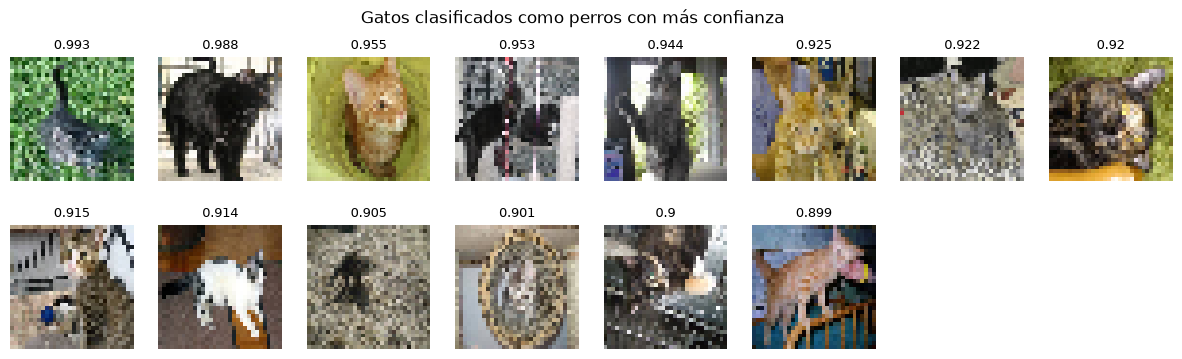

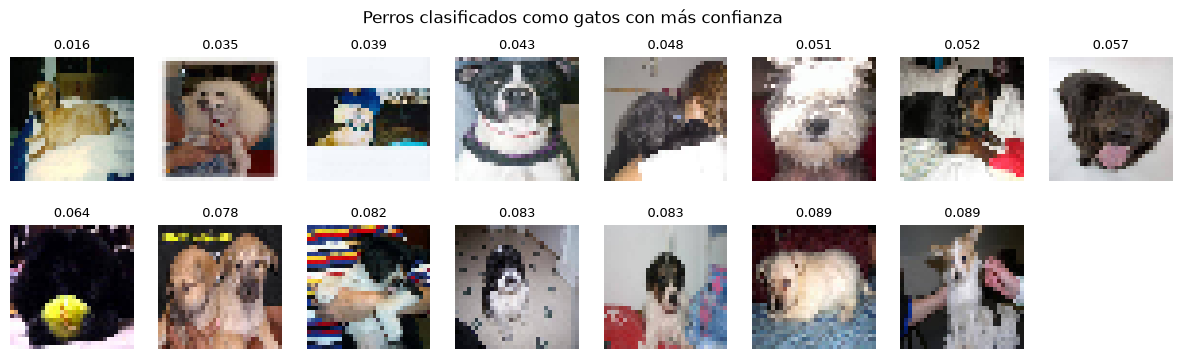

In [57]:
def mostrar_seleccionadas(indices, titulo):
    plt.figure(figsize=(15, 4))
    for posicion, i in enumerate(indices):
        plt.subplot(2, 8, posicion + 1)
        plt.imshow(X_test[i])
        plt.title(str(round(probabilidades[i], 3)), fontsize=9)
        plt.axis("off")
    plt.suptitle(titulo)
    plt.show()

mostrar_seleccionadas(peores_gatos, "Gatos clasificados como perros con más confianza")
mostrar_seleccionadas(peores_perros, "Perros clasificados como gatos con más confianza")

#### - Entrega final:

In [59]:
print("Imágenes seleccionadas para el CAPTCHA:\n")

for i in peores_gatos:
    print(nombres_test[i], "- probabilidad de perro:", round(probabilidades[i], 3))

for i in peores_perros:
    print(nombres_test[i], "- probabilidad de perro:", round(probabilidades[i], 3))

Imágenes seleccionadas para el CAPTCHA:

./data/github_test/cat.11793.jpg - probabilidad de perro: 0.993
./data/github_test/cat.11929.jpg - probabilidad de perro: 0.988
./data/github_test/cat.11636.jpg - probabilidad de perro: 0.955
./data/github_test/cat.11432.jpg - probabilidad de perro: 0.953
./data/github_test/cat.12170.jpg - probabilidad de perro: 0.944
./data/github_test/cat.12330.jpg - probabilidad de perro: 0.925
./data/github_test/cat.10820.jpg - probabilidad de perro: 0.922
./data/github_test/cat.10921.jpg - probabilidad de perro: 0.92
./data/github_test/cat.11899.jpg - probabilidad de perro: 0.915
./data/github_test/cat.11515.jpg - probabilidad de perro: 0.914
./data/github_test/cat.11399.jpg - probabilidad de perro: 0.905
./data/github_test/cat.12127.jpg - probabilidad de perro: 0.901
./data/github_test/cat.12182.jpg - probabilidad de perro: 0.9
./data/github_test/cat.11739.jpg - probabilidad de perro: 0.899
./data/github_test/dog.8951.jpg - probabilidad de perro: 0.016
./d

#### **EXTRA**

## Extra: Image Augmentation

Repetimos los pasos 3 a 5 generando variaciones sintéticas de las imágenes de entrenamiento (giros, rotaciones, desplazamientos y zoom). Buscamos dos cosas:

1. **Reducir el sobreajuste:** si el modelo nunca ve dos veces la misma imagen, no puede memorizarlas y debería reducirse la brecha entre train y validación.
2. **Contrastar la selección de imágenes:** comparar los ficheros que elige este modelo con los del anterior. Las imágenes que ambos fallan con alta confianza son candidatas más sólidas para el CAPTCHA, porque el error no depende de un modelo concreto.

### Configuración del generador

Definimos las transformaciones que se aplicarán aleatoriamente a cada imagen: rotaciones de hasta 20 grados, desplazamientos y zoom del 20%, y volteo horizontal.

No incluimos volteo vertical porque un animal boca abajo no es una imagen realista, y entrenar con casos que nunca van a aparecer en producción no aporta nada al modelo.

In [60]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

Visualización rápida

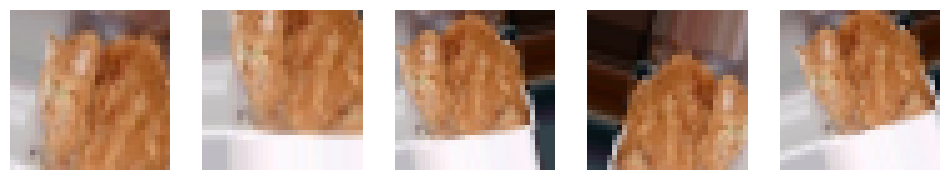

In [61]:
plt.figure(figsize=(12, 3))
imagen = X_train[0].reshape(1, 32, 32, 3)
i = 0
for lote in datagen.flow(imagen, batch_size=1):
    plt.subplot(1, 5, i + 1)
    plt.imshow(lote[0])
    plt.axis("off")
    i = i + 1
    if i == 5:
        break
plt.show()

Entrenamiento (con la misma arquitectura)

### Cambios respecto al modelo anterior

La arquitectura es idéntica, para que la comparación sea justa. Lo que cambia es cómo se alimenta el entrenamiento:

- **Los datos de train pasan por el generador**, que aplica una transformación aleatoria distinta a cada imagen en cada época.
- **La validación se separa manualmente**, porque **validation_split** no funciona cuando los datos vienen de un generador. Cortamos el último 20% del train, que ya está barajado.
- **La validación no lleva augmentation:** se valida con imágenes reales, ya que lo que queremos medir es el rendimiento sobre fotos normales.
- **Más paciencia (10) y más épocas (100):** con augmentation el problema es más difícil y la curva de validación más ruidosa, así que el modelo necesita más tiempo para converger.

In [62]:
model2 = Sequential()
model2.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)))
model2.add(MaxPooling2D((2, 2)))
model2.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model2.add(MaxPooling2D((2, 2)))
model2.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model2.add(MaxPooling2D((2, 2)))
model2.add(Flatten())
model2.add(Dense(128, activation="relu"))
model2.add(Dropout(0.5))
model2.add(Dense(1, activation="sigmoid"))

model2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Separamos validación a mano
X_val = X_train[3200:]
y_val = y_train[3200:]
X_train2 = X_train[:3200]
y_train2 = y_train[:3200]

early_stopping2 = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history2 = model2.fit(datagen.flow(X_train2, y_train2, batch_size=32),
                      epochs=100,
                      validation_data=(X_val, y_val),
                      callbacks=[early_stopping2])

Epoch 1/100


c:\Users\User\Documents\GitHub\MAR26\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4997 - loss: 0.6957 - val_accuracy: 0.4825 - val_loss: 0.6985
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5100 - loss: 0.6909 - val_accuracy: 0.5863 - val_loss: 0.6808
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5581 - loss: 0.6840 - val_accuracy: 0.5900 - val_loss: 0.6609
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5909 - loss: 0.6729 - val_accuracy: 0.5713 - val_loss: 0.6658
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5922 - loss: 0.6680 - val_accuracy: 0.6062 - val_loss: 0.6509
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6141 - loss: 0.6559 - val_accuracy: 0.6250 - val_loss: 0.6362
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6228 - loss: 0.6481 - val_accuracy: 0.6125 - val_loss: 0.6426
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6363 - loss: 0.6443 - val_accuracy

In [65]:
mejor_epoca2 = np.argmin(history2.history["val_loss"])
print("Mejor época:", mejor_epoca2 + 1)
print("Mejor val_loss:", history2.history["val_loss"][mejor_epoca2])
print("Épocas entrenadas:", len(history2.history["loss"]))

Mejor época: 49
Mejor val_loss: 0.48735615611076355
Épocas entrenadas: 59


Visualización gráfica

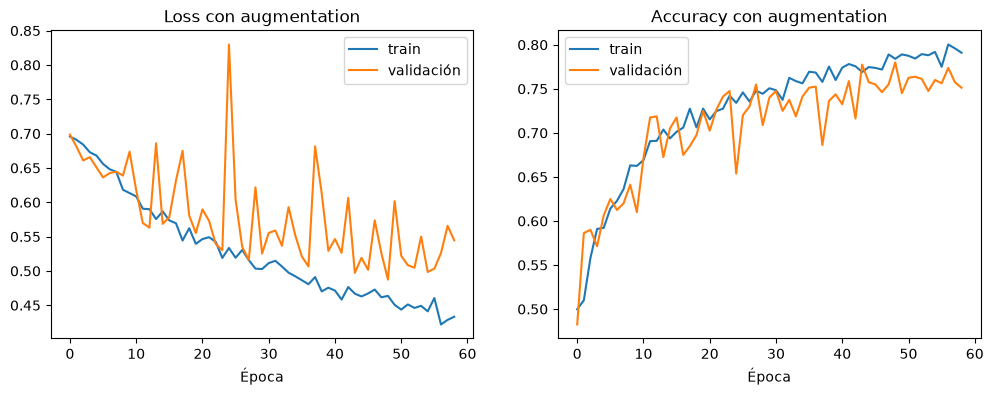

In [67]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history["loss"], label="train")
plt.plot(history2.history["val_loss"], label="validación")
plt.title("Loss con augmentation")
plt.xlabel("Época")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history["accuracy"], label="train")
plt.plot(history2.history["val_accuracy"], label="validación")
plt.title("Accuracy con augmentation")
plt.xlabel("Época")
plt.legend()

plt.show()

### Historial de entrenamiento con augmentation

El entrenamiento se detuvo en la **época 59**, recuperando los pesos de la **época 49** (val_loss 0.4874).

Las curvas son radicalmente distintas a las del modelo base:

- **Ambas curvas de loss descienden juntas** durante todo el entrenamiento, sin el punto de divergencia que veíamos antes. El modelo no llega a memorizar porque nunca ve dos veces la misma imagen.
- **La curva de validación es mucho más ruidosa**, con picos pronunciados. Es consecuencia de la augmentation: cada época entrena con transformaciones aleatorias distintas y el modelo llega a cada evaluación en un estado ligeramente diferente. Por eso ampliamos la paciencia a 10: con la paciencia anterior, el pico de la época 24 habría cortado el entrenamiento en falso.
- **En accuracy, train y validación avanzan casi solapadas** hasta el final, donde se separan ligeramente (0.80 frente a 0.75). Frente a los 18 puntos de diferencia del modelo base, aquí la brecha se queda en 5.

**Comparativa de resultados:**

| | Modelo base | Con augmentation |
|---|---|---|
| Mejor época | 8 | 49 |
| Mejor val_loss | 0.5677 | 0.4874 |
| Épocas entrenadas | 13 | 59 |

La mejora más significativa no es la val_loss (un 14% mejor), sino que el modelo haya podido **seguir aprendiendo durante 49 épocas** en lugar de estancarse a las 8. La augmentation no aporta un ajuste marginal: cambia el techo de lo que el modelo puede aprender con los mismos 4000 datos de partida.

Evaluacióno del modelo

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7700 - loss: 0.4857
Loss en test: 0.485687792301178
Accuracy en test: 0.7699999809265137
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

        gato       0.81      0.70      0.75       500
       perro       0.74      0.84      0.78       500

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



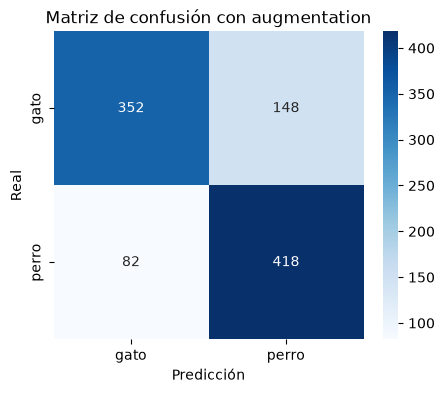

In [68]:
# Paso 4 con el modelo 2
loss_test2, accuracy_test2 = model2.evaluate(X_test, y_test)
print("Loss en test:", loss_test2)
print("Accuracy en test:", accuracy_test2)

probabilidades2 = model2.predict(X_test).flatten()
predicciones2 = (probabilidades2 > 0.5).astype(int)

print(classification_report(y_test, predicciones2, target_names=["gato", "perro"]))

matriz2 = confusion_matrix(y_test, predicciones2)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz2, annot=True, fmt="d", cmap="Blues",
            xticklabels=["gato", "perro"],
            yticklabels=["gato", "perro"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión con augmentation")
plt.show()

### Evaluación del modelo con augmentation

El modelo alcanza un **77% de accuracy** en test frente al 71% del modelo base, y la loss baja de 0.583 a 0.486. La mejora se consigue sin modificar la arquitectura, únicamente generando variaciones de las mismas 4000 imágenes de partida.

**El comportamiento entre clases sí ha cambiado.** El modelo base fallaba de forma simétrica (140 gatos y 150 perros); este comete **148 errores en gatos y solo 82 en perros**. Se refleja en el recall: 0.70 para gato frente a 0.84 para perro. El modelo identifica bien a los perros pero se le escapan más gatos, y ante la duda tiende a predecir perro.

Esto afecta a la selección del punto 5: el 10% de cada grupo de errores ya no produce cantidades equivalentes, sino 14 gatos y 8 perros.

Selección

In [69]:
# Paso 5 con el modelo 2
indices_gatos_fallados2 = []
indices_perros_fallados2 = []

for i in range(len(y_test)):
    if y_test[i] == 0 and predicciones2[i] == 1:
        indices_gatos_fallados2.append(i)
    if y_test[i] == 1 and predicciones2[i] == 0:
        indices_perros_fallados2.append(i)

gatos_ordenados2 = sorted(indices_gatos_fallados2, key=lambda i: probabilidades2[i], reverse=True)
perros_ordenados2 = sorted(indices_perros_fallados2, key=lambda i: probabilidades2[i])

peores_gatos2 = gatos_ordenados2[:int(len(gatos_ordenados2) * 0.1)]
peores_perros2 = perros_ordenados2[:int(len(perros_ordenados2) * 0.1)]

print("Seleccionados:", len(peores_gatos2), "gatos y", len(peores_perros2), "perros")

Seleccionados: 14 gatos y 8 perros


In [70]:
gatos_comunes = set(peores_gatos) & set(peores_gatos2)
perros_comunes = set(peores_perros) & set(peores_perros2)

print("Gatos en ambas selecciones:", len(gatos_comunes))
print("Perros en ambas selecciones:", len(perros_comunes))

for i in gatos_comunes:
    print(nombres_test[i])
for i in perros_comunes:
    print(nombres_test[i])

Gatos en ambas selecciones: 4
Perros en ambas selecciones: 1
./data/github_test/cat.11739.jpg
./data/github_test/cat.11793.jpg
./data/github_test/cat.12127.jpg
./data/github_test/cat.12182.jpg
./data/github_test/dog.9415.jpg


Imágenes que los 2 modelos fallan

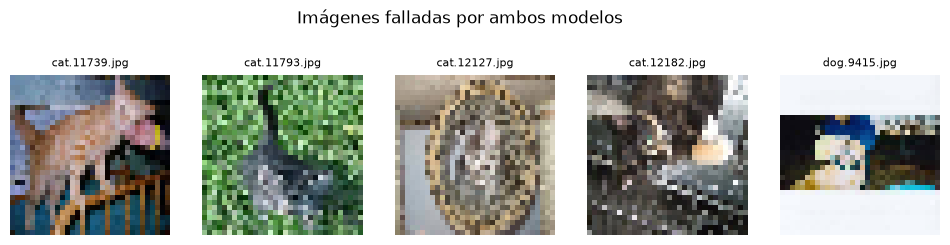

In [71]:
plt.figure(figsize=(12, 3))
todas_comunes = list(gatos_comunes) + list(perros_comunes)
for posicion, i in enumerate(todas_comunes):
    plt.subplot(1, 5, posicion + 1)
    plt.imshow(X_test[i])
    plt.title(nombres_test[i].split("/")[-1], fontsize=8)
    plt.axis("off")
plt.suptitle("Imágenes falladas por ambos modelos")
plt.show()

### Comparación de las selecciones

Cruzando las imágenes seleccionadas por ambos modelos, **5 aparecen en las dos listas**: 4 gatos y 1 perro.

La cifra puede parecer baja, pero es muy significativa. Cada modelo selecciona sus imágenes de entre 500 candidatas por clase, y que 4 de las 14 elegidas coincidan está muy por encima de lo que produciría el azar. Se trata de dos modelos entrenados de forma distinta, uno de ellos con un sobreajuste evidente y el otro no, que aun así señalan las mismas fotografías.

Esta coincidencia es relevante para el objetivo de negocio. Una imagen que falla un único modelo puede reflejar una peculiaridad de ese modelo concreto. Una que fallan ambos con más del 90% de confianza apunta a que la ambigüedad está en la propia imagen, no en el clasificador. Son, por tanto, las candidatas más sólidas para el CAPTCHA: las que previsiblemente engañarían también a otros sistemas automáticos distintos de los aquí entrenados.